# 45 — Video tensors, clips, and temporal sampling

Lecture 10 begins with a simple change: a video is an image sequence, so classification can depend on *what changes over time*, not only what appears in a frame.

In this notebook we will:
1. reason about video tensor axes and storage;
2. visualize a controlled motion dataset;
3. sample short clips from longer videos;
4. test what single-frame and order-blind fusion cannot infer;
5. compare order-aware late fusion with early frame stacking.

The videos are synthetic so that labels and motion are unambiguous. No real-video download or model training is needed yet. Later notebooks will introduce 3D CNNs, two-stream motion models, and temporal sequence models.

Based on [CS231n Spring 2025 Lecture 10](https://cs231n.stanford.edu/2025/schedule.html) and the locally saved lecture references in `notes/_references/10-video/`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

torch.manual_seed(7)
np.random.seed(7)
CLASS_NAMES = ("right", "left")

## 1. Represent a video as a tensor

For one RGB video, we will use `(T, C, H, W)`: time, channels, height, width. A batch is `(N, T, C, H, W)`. Many PyTorch video layers, including `Conv3d`, expect `(N, C, T, H, W)`. The data are the same; only the axis order changes.

If a clip has `T=8`, `C=3`, `H=W=16`, and each value is `float32`, one uncompressed clip stores

$$8\cdot3\cdot16\cdot16\cdot4=24{,}576\text{ bytes}.$$

Real videos are much larger, which is why models often train on short, spatially resized clips sampled from long videos.

### Exercise 1 — Identify and rearrange the axes

Convert a batch from `(N,T,C,H,W)` to `(N,C,T,H,W)` using `permute`. Predict the resulting shape before running the assertion.

In [2]:
def make_motion_pair(
    number_of_frames=8, height=16, width=16, square_size=3
):
    """Return two videos with exactly the same frames in opposite order."""
    if number_of_frames < 2 or width < number_of_frames + square_size + 2:
        raise ValueError("the square needs room to move across the frames")
    right = torch.zeros(number_of_frames, 3, height, width)
    row = height // 2 - square_size // 2
    for t in range(number_of_frames):
        column = 2 + t
        right[t, :, row:row + square_size, column:column + square_size] = 1
    left = right.flip(0).clone()
    return right, left

right_video, left_video = make_motion_pair()
videos = torch.stack((right_video, left_video))  # (N, T, C, H, W)
labels = torch.tensor([0, 1])
assert videos.shape == (2, 8, 3, 16, 16)
assert torch.equal(right_video.flip(0), left_video)

In [ ]:
# move channels before time without changing pixel values.
conv3d_batch = videos.permute(0, 2, 1, 3, 4)

assert conv3d_batch.shape == (2, 3, 8, 16, 16)
assert torch.equal(conv3d_batch.permute(0, 2, 1, 3, 4), videos)
print("Video-layer shape:", tuple(conv3d_batch.shape))

Video-layer shape: (2, 3, 8, 16, 16)


## 2. See motion as a sequence

A frame grid exposes the temporal order. Both videos below have the same object, colors, and collection of frames. Their labels differ only because the frames are ordered differently.

For an isolated frame, a white square at a particular position does *not* reveal whether it arrived from the left or will travel left next. This is an intentionally strict test for order-sensitive classification.

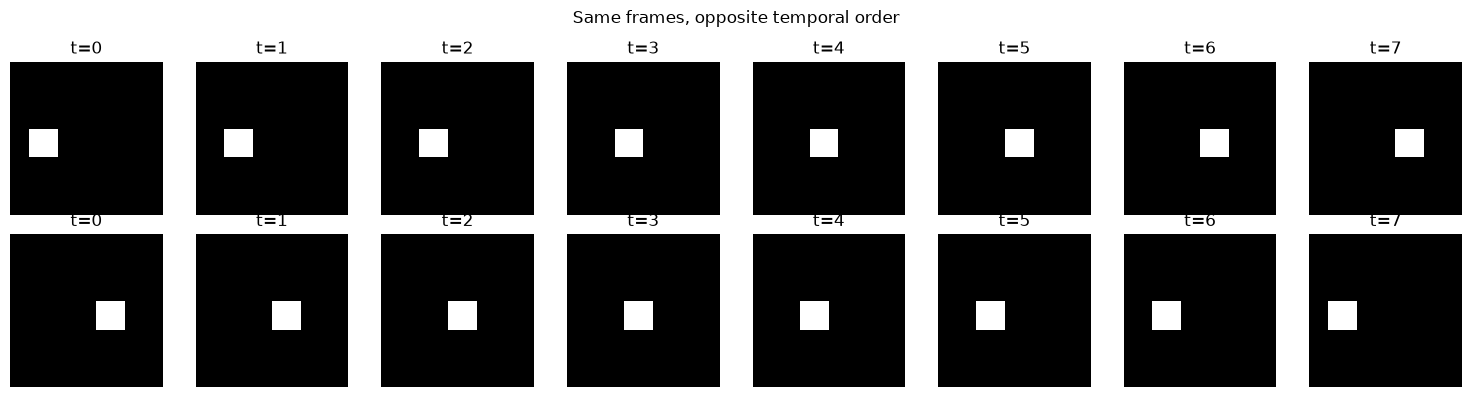

Temporal mean images are exactly equal.


In [4]:
fig, axes = plt.subplots(2, videos.shape[1], figsize=(15, 4))
for video_index in range(2):
    for t in range(videos.shape[1]):
        axes[video_index, t].imshow(videos[video_index, t].permute(1, 2, 0))
        axes[video_index, t].set_title(f"t={t}")
        axes[video_index, t].axis("off")
    axes[video_index, 0].set_ylabel(
        CLASS_NAMES[int(labels[video_index])], rotation=90, fontsize=12
    )
fig.suptitle("Same frames, opposite temporal order")
plt.tight_layout()
plt.show()

assert torch.equal(videos[0].mean(dim=0), videos[1].mean(dim=0))
print("Temporal mean images are exactly equal.")

## 3. Training on short clips

A video may have thousands of frames; a model usually sees only a short clip. Choose a starting frame and a **temporal stride** (step between selected frames). For a clip of length $L$:

$$i_k=\text{start}+k\cdot\text{stride},\qquad k=0,\ldots,L-1.$$

The last index must stay below $T$. A larger stride spans more elapsed time with the same number of input frames, but skips intermediate motion. The `stride` here is temporal sampling stride, not a convolution stride.

### Exercise 2 — Implement contiguous and strided sampling

Fill in `sample_clip_indices`. For our 8-frame video, `start=1`, `length=3`, `stride=2` should select frames `[1,3,5]`.

In [7]:
def sample_clip_indices(total_frames, start, length, stride=1):
    """Return the ordered indices of one valid clip."""
    if total_frames <= 0 or start < 0 or length <= 0 or stride <= 0:
        raise ValueError("frame counts, clip length, and stride must be valid")
    # construct start + k * stride for k = 0, ..., length - 1.
    indices = [start + k * stride for k in range(length)]
    # reject a clip whose last index is outside the video.
    if indices[-1] >= total_frames:
        raise ValueError("clip extends beyond the video")
    return indices

sampled_indices = sample_clip_indices(8, start=1, length=3, stride=2)
assert np.array_equal(sampled_indices, [1, 3, 5])
assert np.array_equal(sample_clip_indices(8, 0, 4), [0, 1, 2, 3])
print("Sampled frames:", sampled_indices)

Sampled frames: [1, 3, 5]


A *contiguous* clip uses stride 1. A *strided* clip uses a larger step. At test time, a model can process several clips from one video and combine their predictions. We will implement a simple multi-clip example after the order experiments.

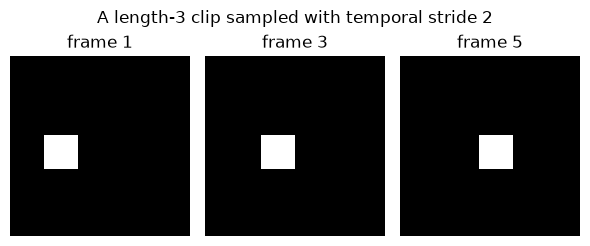

In [8]:
# Reference visualization uses the intended indices [1, 3, 5],
# so this cell can be run even before Exercise 2 is complete.
preview_indices = [1, 3, 5]
fig, axes = plt.subplots(1, len(preview_indices), figsize=(6, 2.5))
for axis, t in zip(axes, preview_indices):
    axis.imshow(right_video[t].permute(1, 2, 0))
    axis.set_title(f"frame {t}")
    axis.axis("off")
fig.suptitle("A length-3 clip sampled with temporal stride 2")
plt.tight_layout()
plt.show()

## 4. A single frame and order-blind fusion

A simple baseline runs a 2D image model on individual frames, then averages its frame scores or probabilities. This can work if action appearance is recognizable in a frame. It cannot reliably resolve our special pair: both videos contain *exactly the same frames*.

The code below uses a transparent toy frame-score function rather than a trained CNN. Its score is based on the square's horizontal position. It is deliberately order-blind: applying it to each frame and averaging cannot distinguish a sequence from its reversal.

### Exercise 3 — Compare frame-score averaging

Calculate one score pair per frame and then average across time. What should happen to the two video-level averages?

In [9]:
def frame_position_scores(frame):
    """Toy two-class scores based only on one frame's square position."""
    horizontal_energy = frame.mean(dim=0).sum(dim=0)  # (W,)
    x = torch.arange(frame.shape[-1], dtype=frame.dtype)
    center_x = (horizontal_energy * x).sum() / horizontal_energy.sum()
    centered_x = center_x - (frame.shape[-1] - 1) / 2
    return torch.stack((centered_x, -centered_x))  # (right_score, left_score)

# Demonstrate one frame score before computing video-level scores.
print("First right-video frame scores:", frame_position_scores(right_video[0]))

First right-video frame scores: tensor([-4.5000,  4.5000])


In [26]:
(
    right_video[0].shape,
    right_video[0].mean(dim=0).shape,
    right_video[0].mean(dim=0).sum(dim=0).shape,
)

(torch.Size([3, 16, 16]), torch.Size([16, 16]), torch.Size([16]))

In [22]:
# for each video, stack its per-frame score pairs into (T, 2).
N, T = videos.shape[:2]
per_frame_scores = torch.zeros((N, T, 2))

for t in range(T):
    for n in range(N):
        per_frame_scores[n,t] = frame_position_scores(videos[n,t])
# average over time, obtaining one (2,) score vector per video.
video_average_scores = per_frame_scores.mean(dim=1)

assert per_frame_scores.shape == (2, 8, 2)
assert video_average_scores.shape == (2, 2)
torch.testing.assert_close(video_average_scores[0], video_average_scores[1])
print("Mean scores:", video_average_scores)

Mean scores: tensor([[-1.,  1.],
        [-1.,  1.]])


## 5. Order-aware late fusion

**Late fusion** first extracts a feature from each frame and then combines features. The combination need not be an average: concatenation, an RNN, or attention can preserve temporal order.

Our toy feature is the square's horizontal center. The first-to-last displacement

$$\Delta x=x_{T-1}-x_0$$

is positive for movement to the right and negative for movement to the left. It is a simple order-aware feature, not a complete real-world motion model.

### Exercise 4 — Recover direction from temporal order

Extract one center value per frame, calculate each video's first-to-last displacement, and infer labels using the sign.

In [23]:
def square_center_x(frame):
    """Return the square's horizontal center from a synthetic frame."""
    energy = frame.mean(dim=0).sum(dim=0)
    positions = torch.arange(frame.shape[-1], dtype=frame.dtype)
    return (energy * positions).sum() / energy.sum()

In [29]:
# extract a (N, T) array of horizontal centers.
N, T = videos.shape[:2]
centers = torch.zeros((N, T))

for t in range(T):
    for n in range(N):
        centers[n,t] = square_center_x(videos[n,t])

# subtract first-frame center from last-frame center for each video.
displacement = centers[:, -1] - centers[:, 0]
# centers[:, -1]  last frame of every video   → (2,)
# centers[:, 0]   first frame of every video  → (2,)
# difference                                  → (2,)

# classify positive displacement as right (0), negative as left (1).
motion_predictions = torch.where(displacement > 0, 0, 1)

assert centers.shape == (2, 8)
torch.testing.assert_close(displacement, torch.tensor([7.0, -7.0]))
assert torch.equal(motion_predictions, labels)
print("Displacements:", displacement)
print("Predictions:", [CLASS_NAMES[int(x)] for x in motion_predictions])

Displacements: tensor([ 7., -7.])
Predictions: ['right', 'left']


## 6. Early fusion: stack frames before feature extraction

**Early fusion** combines raw frames before a 2D CNN. If a clip has shape `(N,T,C,H,W)`, stacking time into the channel axis produces `(N,T*C,H,W)`. A 2D filter can use different weights for different frame slots, so it *can* learn order-sensitive patterns in a fixed-length clip.

This is different from a 3D convolution. In early fusion, time is baked into fixed input channels; a filter does not slide over time. A 3D filter is reused as it slides through time. [Notebook 46](./46_3d_convolution_and_spatiotemporal_receptive_fields.ipynb) will explore that distinction.

### Exercise 5 — Stack frame channels and verify the 2D layer shape

In [30]:
videos.shape

torch.Size([2, 8, 3, 16, 16])

In [34]:
# move T and C next to each other and merge them into T*C.
N, T, C, H, W = videos.shape
early_fusion_input = videos.reshape((N, T*C, W, H))

assert early_fusion_input.shape == (2, 24, 16, 16)
# The first three channels should be the first RGB frame.
torch.testing.assert_close(early_fusion_input[:, :3], videos[:, 0])

# A toy Conv2d accepts the stacked clip as a single image-like tensor.
early_filter = torch.nn.Conv2d(in_channels=24, out_channels=4, kernel_size=3, padding=1)
early_features = early_filter(early_fusion_input)
assert early_features.shape == (2, 4, 16, 16)
print("Early-fusion feature shape:", tuple(early_features.shape))

Early-fusion feature shape: (2, 4, 16, 16)


## 7. Testing with more than one clip

A single sampled clip may miss the important action. Testing can sample several clips, obtain one score vector per clip, and average those score vectors. This reduces dependence on one arbitrary start time, but it still cannot recover temporal order if every clip model itself ignores order.

Below we use two overlapping clips and our order-aware displacement feature. For a real classifier, `clip_scores` would instead be its predicted scores or probabilities.

In [35]:
clip_starts = (0, 3)
clip_length = 4
for video_index, video in enumerate(videos):
    clip_scores = []
    for start in clip_starts:
        clip = video[start:start + clip_length]
        difference = square_center_x(clip[-1]) - square_center_x(clip[0])
        clip_scores.append(torch.stack((difference, -difference)))
    clip_scores = torch.stack(clip_scores)  # (number_of_clips, classes)
    average_scores = clip_scores.mean(dim=0)
    print(
        CLASS_NAMES[int(labels[video_index])],
        "clip scores:", clip_scores.tolist(),
        "average:", average_scores.tolist(),
    )
    assert int(average_scores.argmax()) == int(labels[video_index])

right clip scores: [[3.0, -3.0], [3.0, -3.0]] average: [3.0, -3.0]
left clip scores: [[-3.0, 3.0], [-3.0, 3.0]] average: [-3.0, 3.0]


## 8. What this toy experiment does—and does not—show

The pair proves an information limitation: if the input to a classifier is one frame, or a commutative average over the same frames, it cannot uniquely identify the direction here. An order-aware representation succeeds because it receives information those baselines discard.

This does **not** mean single-frame CNNs are useless on real action datasets. Appearance and scene context often provide strong clues. Nor does first-to-last displacement solve complex actions with changing camera viewpoints, multiple objects, occlusion, or events in the middle of a long video. Later practices will add learned spatial and temporal models.

| Approach | Sees appearance? | Preserves order? | Main limitation here |
| --- | --- | --- | --- |
| One frame | Yes | No | Direction is ambiguous |
| Mean frame scores/features | Yes | No | Reversals have the same mean |
| Order-aware late fusion | Yes | Yes | Our hand-built displacement is simplistic |
| Early frame stacking | Yes | Yes, for fixed frame slots | Does not slide its filters through time |
| 3D convolution (next notebook) | Yes | Yes, locally | More computation and finite temporal extent |

## Reflection

Answer briefly in your own words.

1. What does each axis in `(N,C,T,H,W)` represent?
2. Why train on clips instead of full-length videos?
3. How do clip length and temporal sampling stride differ?
4. Why do the two synthetic videos have identical temporal mean images?
5. Why can average frame scores not distinguish their motion directions?
6. How does order-aware late fusion differ from temporal averaging?
7. What information does early fusion preserve, and what is its limitation compared with 3D convolution?
8. Why can test-time averaging over multiple clips be useful?

### Answers

1. number of samples, frame channels, frames, frame height and width
2. videos usually have huge size
3. Clip length is the number of selected frames. Temporal stride is the gap between them. A larger stride keeps the same clip length but spans more time and skips more frames.
4. frames are the same but just in different order
5. The problem is that averaging scores discards which position came first or last, so reversed videos have the same average.
6. in our simple example it just difference between last and first frame. In more complex models it might be positional encoding, RNN hidden state, etc. The first-to-last difference is an order-aware way to combine frame features. RNNs or temporal attention could also do this. Positional encoding by itself supplies order information but is not the fusion method.
7. it preserves frame sequence combined with channels. the limitation is frames length. Early fusion preserves fixed frame slots as separate channels. More precisely, its 2D filter does not slide over time, unlike a 3D filter; it also expects a fixed clip length.
8. different clips might discover different details about video. Several clips cover more of a video, so one unlucky clip is less likely to miss the action. Averaging cannot fix an underlying model that discards order